In [21]:
import numba as nb
import numpy as np
import  os
from typing import Type
import math

from Pyroclast.model.stokes_2D_mg.smoothers.vx.inline_vx import inline_loop_body_vx
from Pyroclast.model.stokes_2D_mg.smoothers.vy.inline_vy import inline_loop_body_vy
from Pyroclast.model.stokes_2D_mg.utils import apply_vx_BC, apply_vy_BC


"""
Internal If implementation of staggered red-black gauss-seidel, offset is 2, and fully staggered implementation,
using cache optimized blocking
"""


@nb.njit(cache=True, parallel=True)
def velocity_smoother_rb_gs(nx1: int, ny1: int,
                            dx: float, dy: float,
                            etap: np.ndarray, etab: np.ndarray,
                            vx: np.ndarray, vy: np.ndarray,
                            relax_v: float, BC: float,
                            vx_rhs: np.ndarray, vy_rhs: np.ndarray, max_iter: int,
                            th: int, cache_a: int):
    y_low_lim = 1
    y_up_lim = nx1 - 1
    for c in range(max_iter):
        # Work Split
        for p in nb.prange(th):
            start_y = (p * (y_up_lim - y_low_lim) / th) + y_low_lim
            end_y = y_up_lim if p + 1 == th else ((p + 1) * (y_up_lim - y_low_lim) / th) + 1

            blocks = math.ceil((end_y - start_y) / cache_a)

            # Iterate through the cache blocks
            for b in range(blocks):
                start_b = start_y + b * cache_a
                end_b = end_y if b + 1 == blocks else start_y + (b + 1) * cache_a

                # Iterate through j, add + 3 for offset for second pass, and vy pass
                for j in range(1, nx1 - 2):
                    for i in range(start_b, end_b):
                        vx[i, j] += c

        apply_vx_BC(vx, BC)
        apply_vy_BC(vy, BC)

nb.set_num_threads(8)

In [22]:
max_iter = 128
nx = 256
ny = 256
dx = 1.0 / (nx - 1)
dy = 1.0 / (ny - 1)
nx1 = nx + 1
ny1 = ny + 1

# Generate random material properties
etab = np.random.rand(ny1, nx1) * 1e19 + 1e19  # Viscosity at basic nodes
etap = np.random.rand(ny1, nx1) * 1e19 + 1e19  # Viscosity at pressure nodes

# Generate solution and rhs arrays
vx = np.zeros((ny1, nx1))
vx_new = np.zeros((ny1, nx1))  # New array for Jacobi update
vy = np.zeros((ny1, nx1))
vx_rhs = np.zeros((ny1, nx1))
vy_rhs = np.zeros((ny1, nx1))

BC = -1.0
relax_v = 0.7

velocity_smoother_rb_gs(nx1=nx1, ny1=ny1,
                        dx=dx, dy=dy,
                        etap=etap, etab=etab,
                        vx=vx, vy=vy,
                        relax_v=relax_v, BC=BC,
                        vx_rhs=vx_rhs, vy_rhs=vy_rhs, max_iter=max_iter,
                        th=8, cache_a=8)



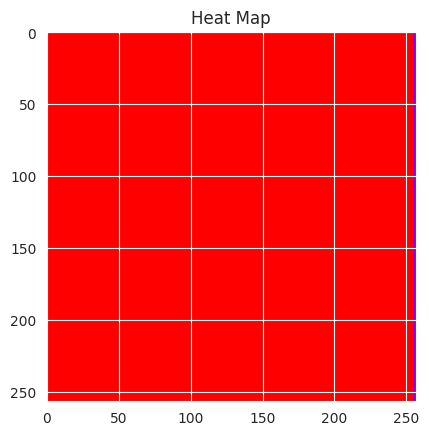

In [23]:
import matplotlib.pyplot as plt

plt.imshow(vx, cmap="rainbow")

# Add Title

plt.title( "Heat Map" )

# Display

plt.show()